In [5]:
import xarray as xr
import numpy as np
from matplotlib import pyplot as plt
plt.rcParams['figure.figsize'] = (12, 6)

In [6]:
import pooch
fname = pooch.retrieve(
    'http://ldeo.columbia.edu/~danielmw/CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc',
    known_hash=None,  downloader=pooch.HTTPDownloader(verify=False)
)
print(fname)

/home/emf2229/.cache/pooch/a379a4cf37bf10809e636b0809c1c88b-CERES_EBAF-TOA_Edition4.0_200003-201701.condensed.nc


In [7]:
ds = xr.open_dataset(fname)
print(ds)

<xarray.Dataset> Size: 737MB
Dimensions:                      (time: 203, lat: 180, lon: 360)
Coordinates:
  * time                         (time) datetime64[ns] 2kB 2000-03-15 ... 201...
  * lat                          (lat) float32 720B -89.5 -88.5 ... 88.5 89.5
  * lon                          (lon) float32 1kB 0.5 1.5 2.5 ... 358.5 359.5
Data variables: (12/14)
    toa_sw_all_mon               (time, lat, lon) float32 53MB ...
    toa_lw_all_mon               (time, lat, lon) float32 53MB ...
    toa_net_all_mon              (time, lat, lon) float32 53MB ...
    toa_sw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_lw_clr_mon               (time, lat, lon) float32 53MB ...
    toa_net_clr_mon              (time, lat, lon) float32 53MB ...
    ...                           ...
    toa_cre_net_mon              (time, lat, lon) float32 53MB ...
    solar_mon                    (time, lat, lon) float32 53MB ...
    cldarea_total_daynight_mon   (time, lat, lon) float32

In [8]:
for var in ds.data_vars:
    print(f"{var:25} : {ds[var].attrs.get('long_name', 'N/A')}")

toa_sw_all_mon            : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon            : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon           : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon            : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon            : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon           : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon            : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon            : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon           : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                 : Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon : Cloud Area 

In [9]:
for var in ds.data_vars:
    print(f"{var:25} : {ds[var].attrs.get('long_name', 'N/A')}")

toa_sw_all_mon            : Top of The Atmosphere Shortwave Flux, Monthly Means, All-Sky conditions
toa_lw_all_mon            : Top of The Atmosphere Longwave Flux, Monthly Means, All-Sky conditions
toa_net_all_mon           : Top of The Atmosphere Net Flux, Monthly Means, All-Sky conditions
toa_sw_clr_mon            : Top of The Atmosphere Shortwave Flux, Monthly Means, Clear-Sky conditions
toa_lw_clr_mon            : Top of The Atmosphere Longwave Flux, Monthly Means, Clear-Sky conditions
toa_net_clr_mon           : Top of The Atmosphere Net Flux, Monthly Means, Clear-Sky conditions
toa_cre_sw_mon            : Top of The Atmosphere Cloud Radiative Effects Shortwave Flux, Monthly Means
toa_cre_lw_mon            : Top of The Atmosphere Cloud Radiative Effects Longwave Flux, Monthly Means
toa_cre_net_mon           : Top of The Atmosphere Cloud Radiative Effects Net Flux, Monthly Means
solar_mon                 : Incoming Solar Flux, Monthly Means
cldarea_total_daynight_mon : Cloud Area 

In [14]:
ds_mean = ds.mean(dim='time')

In [12]:
print(ds.data_vars)

Data variables:
    toa_sw_all_mon               (time, lat, lon) float32 53MB 43.85 ... 0.049
    toa_lw_all_mon               (time, lat, lon) float32 53MB 139.6 ... 168.5
    toa_net_all_mon              (time, lat, lon) float32 53MB -126.4 ... -168.6
    toa_sw_clr_mon               (time, lat, lon) float32 53MB 64.47 ... 0.006
    toa_lw_clr_mon               (time, lat, lon) float32 53MB 136.6 ... 175.8
    toa_net_clr_mon              (time, lat, lon) float32 53MB -143.9 ... -175.9
    toa_cre_sw_mon               (time, lat, lon) float32 53MB 20.62 ... -0.043
    toa_cre_lw_mon               (time, lat, lon) float32 53MB -3.054 ... 7.335
    toa_cre_net_mon              (time, lat, lon) float32 53MB 17.57 ... 7.292
    solar_mon                    (time, lat, lon) float32 53MB 57.13 ... 0.0
    cldarea_total_daynight_mon   (time, lat, lon) float32 53MB 40.0 ... 80.71
    cldpress_total_daynight_mon  (time, lat, lon) float32 53MB 540.9 ... 737.5
    cldtemp_total_daynight_mon   

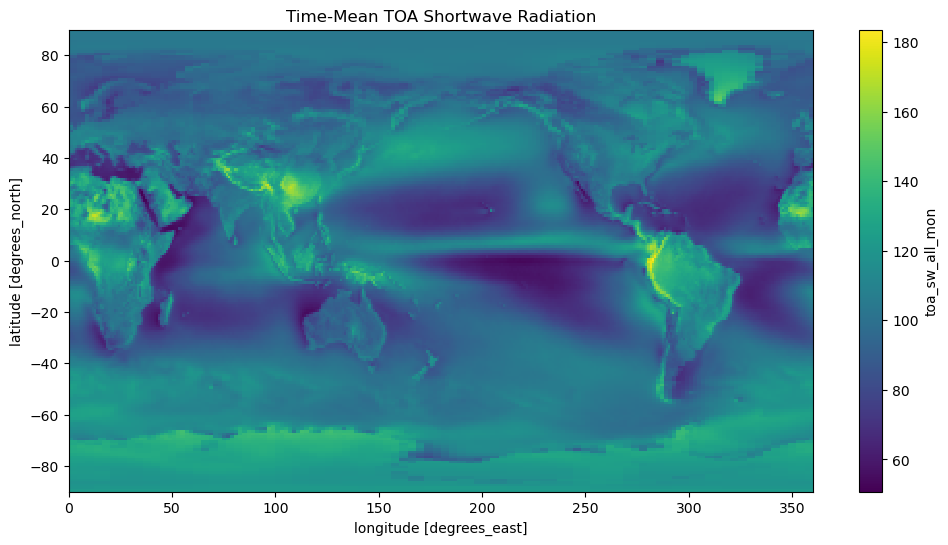

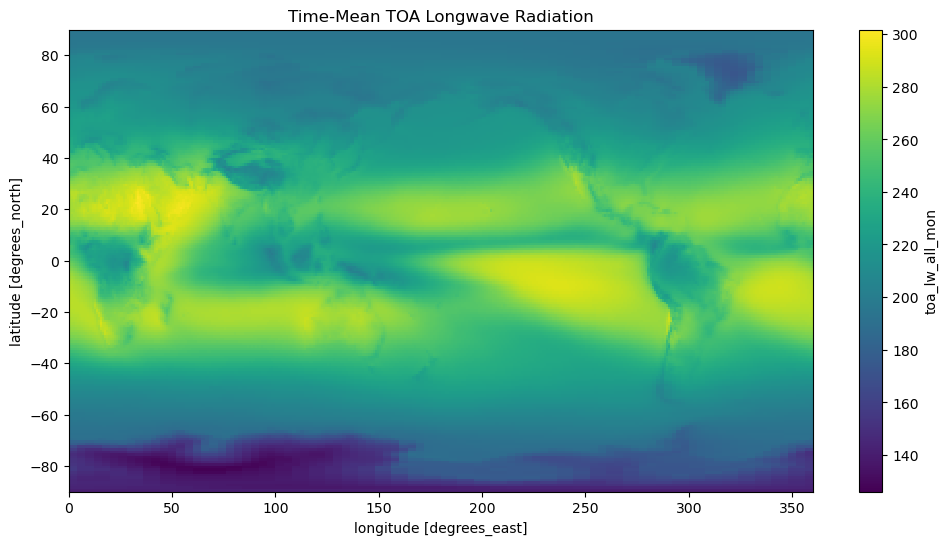

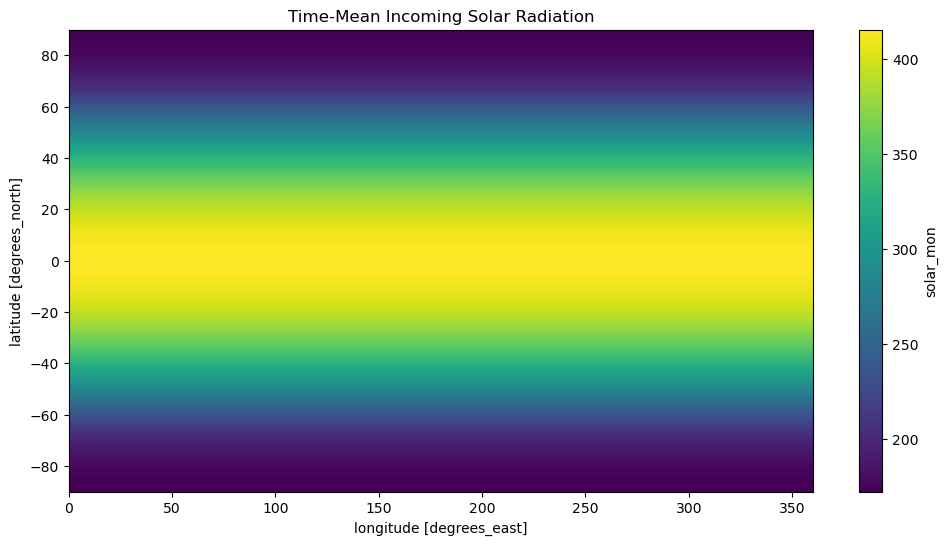

In [19]:
ds_mean = ds.mean(dim='time')

ds_mean['toa_sw_all_mon'].plot()
plt.title("Time-Mean TOA Shortwave Radiation")
plt.show()

ds_mean['toa_lw_all_mon'].plot()
plt.title("Time-Mean TOA Longwave Radiation")
plt.show()

ds_mean['solar_mon'].plot()
plt.title("Time-Mean Incoming Solar Radiation")
plt.show()

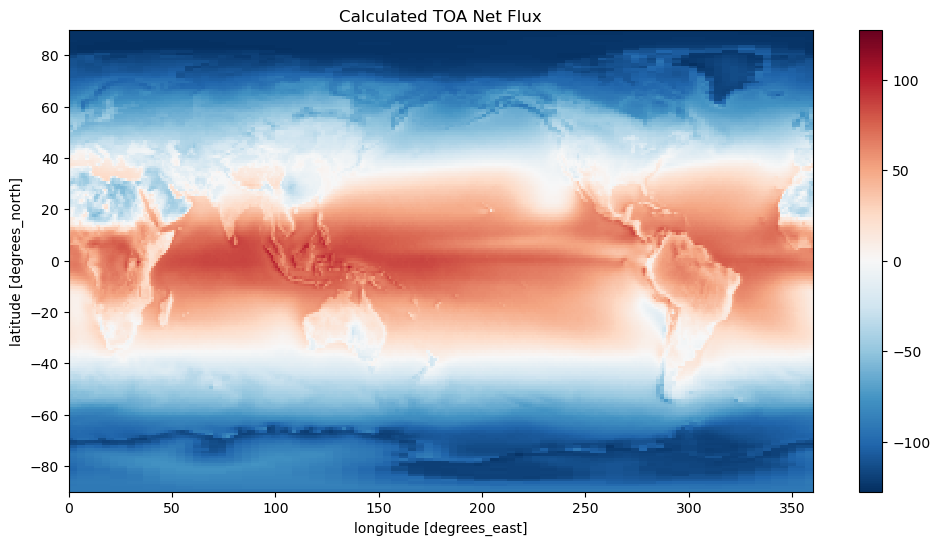

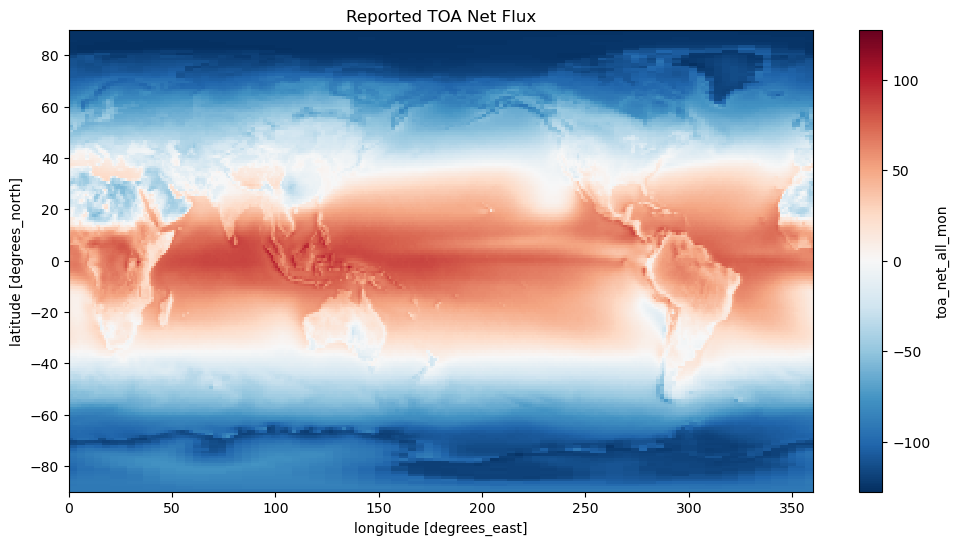

In [21]:
net_calc = ds_mean['solar_mon'] - ds_mean['toa_sw_all_mon'] - ds_mean['toa_lw_all_mon']

net_calc.plot()
plt.title("Calculated TOA Net Flux")
plt.show()

ds_mean['toa_net_all_mon'].plot()
plt.title("Reported TOA Net Flux")
plt.show()

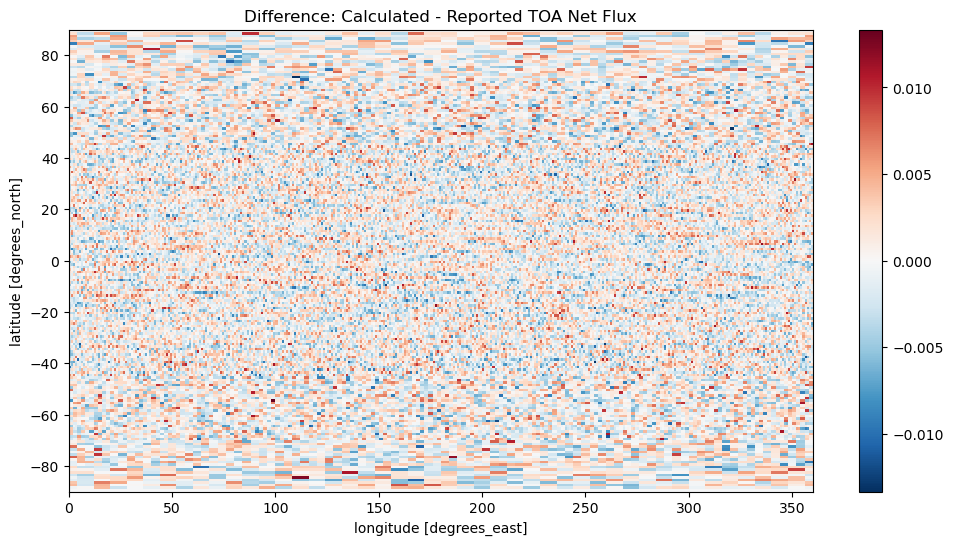

In [22]:
(net_calc - ds_mean['toa_net_all_mon']).plot()
plt.title("Difference: Calculated - Reported TOA Net Flux")
plt.show()

In [23]:
unweighted_mean = ds_mean['toa_net_all_mon'].mean(dim=('lat', 'lon'))
print(unweighted_mean)

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(-28.729012, dtype=float32)


In [25]:
weight = np.cos(np.deg2rad(ds['lat']))
weight.name = "weight"
print(weight)

<xarray.DataArray 'weight' (lat: 180)> Size: 720B
array([0.00872656, 0.02617699, 0.04361945, 0.06104851, 0.07845908,
       0.09584576, 0.11320324, 0.13052624, 0.14780948, 0.16504757,
       0.18223551, 0.19936794, 0.21643965, 0.23344542, 0.25037998,
       0.26723838, 0.28401536, 0.30070582, 0.3173047 , 0.33380693,
       0.35020736, 0.3665012 , 0.38268346, 0.3987491 , 0.4146933 ,
       0.43051115, 0.44619778, 0.4617486 , 0.47715878, 0.49242356,
       0.5075384 , 0.5224986 , 0.5372996 , 0.551937  , 0.56640625,
       0.58070296, 0.59482276, 0.6087614 , 0.62251467, 0.6360782 ,
       0.64944804, 0.66262007, 0.67559016, 0.68835455, 0.70090926,
       0.71325046, 0.72537434, 0.7372773 , 0.7489557 , 0.76040596,
       0.77162457, 0.78260815, 0.7933533 , 0.8038569 , 0.8141155 ,
       0.8241262 , 0.83388585, 0.8433914 , 0.85264015, 0.8616291 ,
       0.87035567, 0.87881714, 0.8870108 , 0.89493436, 0.90258527,
       0.9099613 , 0.9170601 , 0.9238795 , 0.9304176 , 0.9366722 ,
       0.942

In [26]:
weighted_mean = ds_mean['toa_net_all_mon'].weighted(weight).mean(dim=('lat', 'lon'))
print(weighted_mean)

<xarray.DataArray 'toa_net_all_mon' ()> Size: 4B
array(0.8780864, dtype=float32)


In [27]:
solar_global = ds_mean['solar_mon'].weighted(weights).mean(dim=('lat', 'lon'))
lw_global = ds_mean['toa_lw_all_mon'].weighted(weights).mean(dim=('lat', 'lon'))
sw_global = ds_mean['toa_sw_all_mon'].weighted(weights).mean(dim=('lat', 'lon'))

print("Incoming solar:", solar_global.values)
print("Outgoing longwave:", lw_global.values)
print("Outgoing shortwave:", sw_global.values)

Incoming solar: 340.28354
Outgoing longwave: 240.2667
Outgoing shortwave: 99.138596


In [28]:
print("Net:", solar_global.values - lw_global.values - sw_global.values)

Net: 0.8782501


In [30]:
R = 6.371e6 

lat_rad = np.deg2rad(ds['lat'])
lon_rad = np.deg2rad(ds['lon'])

dlat = float(np.abs(lat_rad[1] - lat_rad[0]))
dlon = float(np.abs(lon_rad[1] - lon_rad[0]))

area_1d = (R**2) * dlat * dlon * np.cos(lat_rad)
area_2d = xr.ones_like(ds_mean['toa_net_all_mon']) * area_1d

In [31]:
total_area = area_2d.sum()
earth_area = 4 * np.pi * R**2

print("Sum of pixels:", total_area.values)
print("Area of sphere:", earth_area)

Sum of pixels: 510071600000000.0
Area of sphere: 510064471909788.25


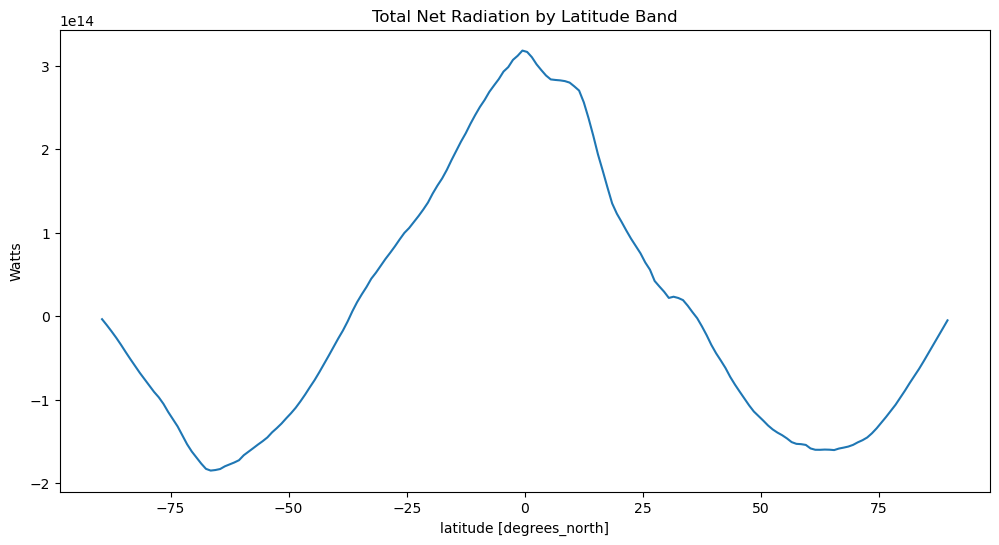

In [32]:
total_power = ds_mean['toa_net_all_mon'] * area_2d
lat_band_power = total_power.sum(dim='lon')

lat_band_power.plot()
plt.title("Total Net Radiation by Latitude Band")
plt.ylabel("Watts")
plt.show()

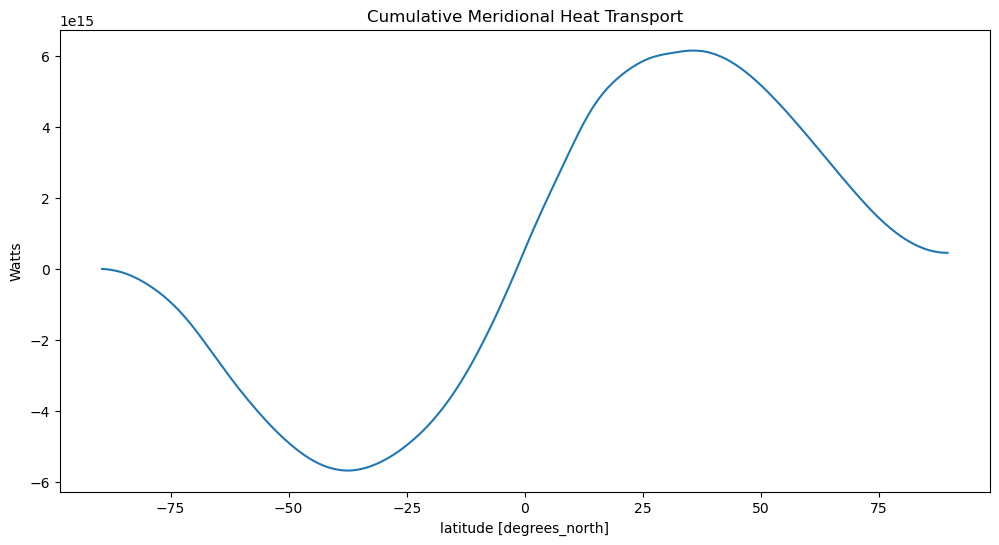

In [33]:
cumulative_transport = lat_band_power.cumsum(dim='lat')

cumulative_transport.plot()
plt.title("Cumulative Meridional Heat Transport")
plt.ylabel("Watts")
plt.show()

In [ ]:
import xarray as xr
import pooch
url = 'https://polarwatch.noaa.gov/erddap/files/nsidcCDRiceSQsh1day/2017/seaice_conc_daily_sh_f17_20170807_v03r01.nc'
fname = pooch.retrieve(url, known_hash='19b74e7e97f1c0786da0c674c4d5e4af0da5b32e2fe8c66a8f1a8a9a1241e73c')
ds_ice = xr.open_dataset(fname, drop_variables='melt_onset_day_seaice_conc_cdr')

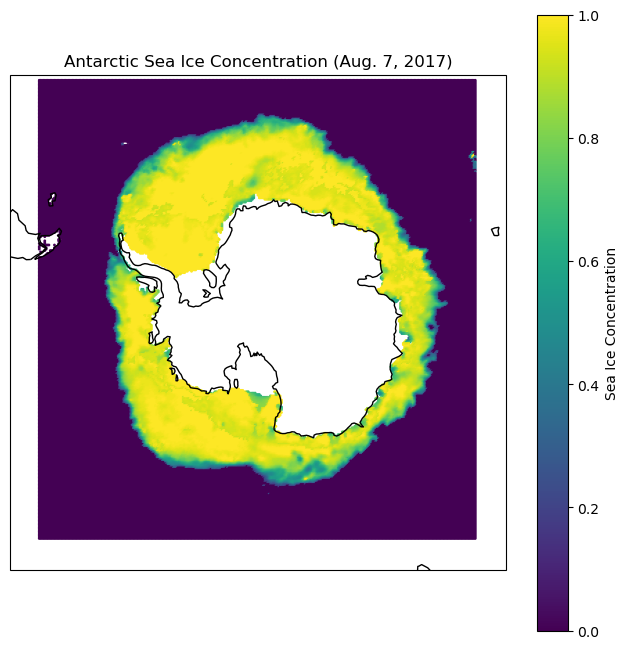

In [19]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

ice = ds_ice['seaice_conc_cdr'].isel(time=0)

ice = ice.where((ice >= 0) & (ice <= 1))

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())

pcm = ax.scatter(
    ds_ice['longitude'].values.flatten(),
    ds_ice['latitude'].values.flatten(),
    c=ice.values.flatten(),
    s=1,
    transform=ccrs.PlateCarree(),
    cmap='viridis',
    vmin=0,
    vmax=1
)

ax.coastlines()
ax.set_extent([-180, 180, -90, -50], crs=ccrs.PlateCarree())
plt.colorbar(pcm, ax=ax, label='Sea Ice Concentration')
plt.title("Antarctic Sea Ice Concentration (Aug. 7, 2017)")
plt.show()

In [20]:
import pandas as pd

url = "http://www.ldeo.columbia.edu/~danielmw/usgs_earthquakes_2014.csv"
df = pd.read_csv(url)

df.head()

,time,latitude,longitude,depth,mag,magType,nst,gap,dmin,rms,net,id,updated,place,type
0,2014-01-31 23:53:37.000,60.252000,-152.7081,90.20,1.10,ml,NaN,NaN,NaN,0.2900,ak,ak11155107,2014-02-05T19:34:41.515Z,"26km S of Redoubt Volcano, Alaska",earthquake
1,2014-01-31 23:48:35.452,37.070300,-115.1309,0.00,1.33,ml,4.0,171.43,0.34200,0.0247,nn,nn00436847,2014-02-01T01:35:09.000Z,"32km S of Alamo, Nevada",earthquake
2,2014-01-31 23:47:24.000,64.671700,-149.2528,7.10,1.30,ml,NaN,NaN,NaN,1.0000,ak,ak11151142,2014-02-01T00:03:53.010Z,"12km NNW of North Nenana, Alaska",earthquake
3,2014-01-31 23:30:54.000,63.188700,-148.9575,96.50,0.80,ml,NaN,NaN,NaN,1.0700,ak,ak11151135,2014-01-31T23:41:25.007Z,"22km S of Cantwell, Alaska",earthquake
4,2014-01-31 23:30:52.210,32.616833,-115.6925,10.59,1.34,ml,6.0,285.00,0.04321,0.2000,ci,ci37171541,2014-02-01T00:13:20.107Z,"10km WNW of Progreso, Mexico",earthquake


In [21]:
print(df.columns)

Index(['time', 'latitude', 'longitude', 'depth', 'mag', 'magType', 'nst',
       'gap', 'dmin', 'rms', 'net', 'id', 'updated', 'place', 'type'],
      dtype='object')


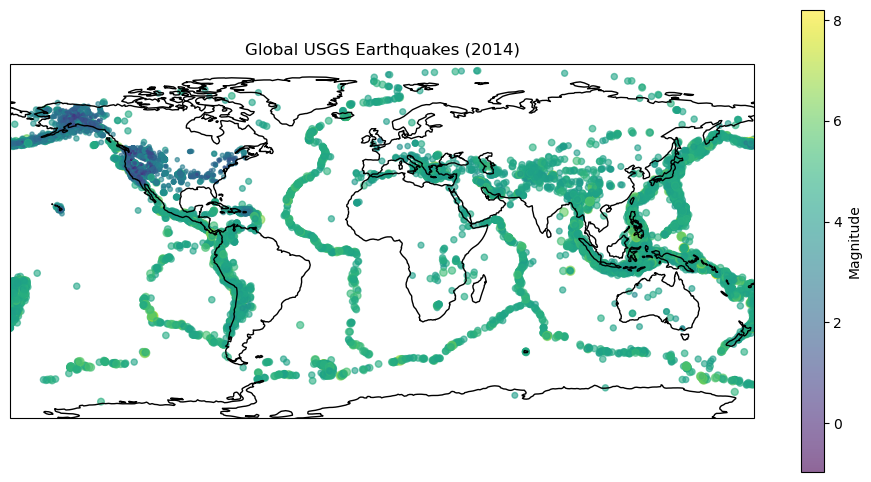

In [22]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

fig = plt.figure(figsize=(12, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

ax.coastlines()

sc = ax.scatter(
    df['longitude'],
    df['latitude'],
    c=df['mag'],
    s=df['mag']**2,
    transform=ccrs.PlateCarree(),
    alpha=0.6
)

plt.colorbar(sc, ax=ax, label='Magnitude')
plt.title("Global USGS Earthquakes (2014)")
plt.show()

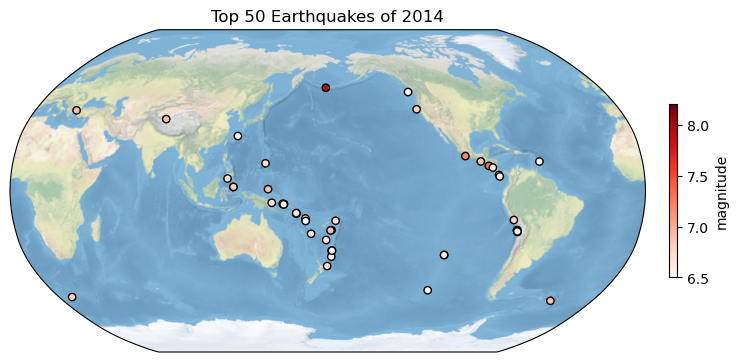

In [28]:
fig = plt.figure(figsize=(10, 5))
ax = plt.axes(projection=ccrs.Robinson(central_longitude=180))

ax.stock_img()
ax.coastlines(linewidth=0)
ax.set_global()

sc = ax.scatter(
    top50['longitude'],
    top50['latitude'],
    c=top50['mag'],
    s=28,
    cmap='Reds',
    vmin=6.5,
    vmax=8.2,
    edgecolors='black',   
    linewidths=1,         
    transform=ccrs.PlateCarree()
)

plt.title("Top 50 Earthquakes of 2014", fontsize=12)

cbar = plt.colorbar(sc, ax=ax, shrink=0.45, pad=0.03)
cbar.set_label("magnitude")

plt.show()